# Hyperparameter Tuning (Optuna)

<div style="text-align: justify">

The following notebook is dedicated to <b>hyperparameter optimisation</b> for the <b>Tau Supersymmetry</b> search analysis. Using <b>Optuna</b> with TPE sampling and median pruning, a k-fold cross-validated search is performed over the hyperparameter space for both XGBoost (BDT) and PyTorch (DNN) classifiers. The best parameters are exported as Hydra-compatible YAML configs for use in subsequent training runs.

</div>

## Pipeline Summary

| Step | Module | Description |
|------|--------|-------------|
| Config | `hydra.compose` | Load analysis, model, and tuning configuration |
| Load | `io.load_dataframe` | Read mc.parquet from feature engineering output |
| Labels | — | Derive ordered class names from `eventOrigin` |
| Prepare | `splits.prepare_features_target` | Separate training features, labels, and weights |
| Split | `splits.kfold_split` | Stratified K-fold split for CV |
| Study | `tuning.create_study` | Create/resume Optuna study with SQLite persistence |
| Optimize | `tuning.bdt_objective` / `tuning.dnn_objective` | K-fold CV objectives with pruning |
| Results | `optuna.visualization` | Optimization history and parameter importance plots |
| Export | `tuning.export_best_params` | Save best params as Hydra-compatible YAML |

The same pipeline is available as a CLI via `python run.py stage=tune` or `make tune`.

## Initialization

### Libraries

Configuration:
* [Hydra](https://hydra.cc/)
* [OmegaConf](https://omegaconf.readthedocs.io/)
* [pyrootutils](https://github.com/ashleve/pyrootutils)

Data Processing:
* [Pandas](https://pandas.pydata.org/)
* [NumPy](https://numpy.org/)

Hyperparameter Optimisation:
* [Optuna](https://optuna.readthedocs.io/)

Machine Learning:
* [XGBoost](https://xgboost.readthedocs.io/en/stable/)
* [PyTorch](https://pytorch.org/)
* [scikit-learn](https://scikit-learn.org/stable/)

Data Visualization:
* [Plotly](https://plotly.com/python/) (Optuna visualizations)

### Notebook

Activating autoreload of imported modules.

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

Initializing the project root.

In [2]:
import pyrootutils

path = pyrootutils.setup_root(
    search_from=__file__ if "__file__" in locals() else ".",
    indicator=".gitignore",
    pythonpath=True,
)

Suppressing unessential warnings and applying ATLAS style.

In [3]:
import optuna

from src.utils import suppress_warnings
from src.visualization.plots import apply_atlas_style

suppress_warnings()
apply_atlas_style()
optuna.logging.set_verbosity(optuna.logging.WARNING)

## Configuration

Loading the Hydra configuration. All analysis parameters (run, region, channel, model hyperparameters, tuning settings) are defined in `configs/` and can be overridden here.

> **Model selection:** change `overrides` to `["model=dnn"]` for DNN tuning.

In [4]:
from hydra import compose, initialize_config_dir

initialize_config_dir(config_dir=str(path / "configs"), version_base="1.3")
cfg = compose(config_name="config")

Resolving input and output directories from config.

In [5]:
from src.processing.analysis import get_output_paths

output_paths = get_output_paths(cfg)
dataframes_dir = path / output_paths["dataframes_dir"]
models_dir = path / output_paths["models_dir"]
plots_dir = path / output_paths["plots_dir"] / "tuning"

models_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

## Data Loading & Preparation

Loading the MC DataFrame produced by the feature engineering pipeline.

In [6]:
from src.processing.io import load_dataframe

df_mc = load_dataframe(dataframes_dir / "mc.parquet")
print(f"Loaded: {len(df_mc):,} events, {len(df_mc.columns)} columns")

Loaded: 9,827,169 events, 58 columns


Optionally subsampling the dataset (stratified by class) to speed up tuning. Controlled by `tuning.subsample_fraction` in the config.

In [7]:
subsample = cfg.tuning.get("subsample_fraction", 1.0)
if subsample < 1.0:
    df_mc = df_mc.groupby("class", group_keys=False).apply(
        lambda g: g.sample(frac=subsample, random_state=cfg.seed)
    )
    print(f"Subsampled to {subsample:.0%}: {len(df_mc):,} events")
else:
    print("Using full dataset (no subsampling)")

Subsampled to 10%: 982,717 events


Deriving ordered class names from `eventOrigin`.

In [8]:
from src.eda.utils import get_class_names

class_names = get_class_names(df_mc)
n_classes = len(class_names)
print(f"Classes ({n_classes}): {class_names}")

Classes (6): ['topquarks', 'wtaunu', 'ztautau', 'diboson', 'other', 'signal']


Separating training features, integer class labels, and per-event sample weights.

In [9]:
from src.models.splits import prepare_features_target

X, y, weights = prepare_features_target(df_mc)
print(f"Feature matrix: {X.shape}")

Feature matrix: (982717, 53)


### Data Split

Split method is controlled by `tuning.split_method`: `"kfold"` for stratified K-fold cross-validation or `"train_test"` for a single stratified train-test split.

In [10]:
from src.models.splits import kfold_split, train_test_split

split_method = cfg.tuning.get("split_method", "kfold")

if split_method == "kfold":
    n_splits = cfg.tuning.n_splits
    folds = kfold_split(X, y, weights, n_splits=n_splits, seed=cfg.seed)
    print(f"K-fold: {n_splits} stratified folds")
else:
    test_size = cfg.tuning.get("test_size", 0.2)
    folds = [train_test_split(X, y, weights, test_size=test_size, seed=cfg.seed)]
    print(f"Train-test split: {test_size:.0%} test")

Train-test split: 20% test


## Optuna Study

Creating or resuming the Optuna study. Studies are persisted in SQLite for automatic resumability.

In [11]:
from src.models.tuning import create_study

storage_path = models_dir / cfg.tuning.storage_filename
study = create_study(cfg, storage_path)
print(f"Study: {study.study_name}")
print(f"Existing trials: {len(study.trials)}")

Study: tau-supersymmetry-search-tuning
Existing trials: 200


## Optimization

### BDT (XGBoost)

Running the BDT objective with XGBoost pruning callbacks. Skip this cell if tuning the DNN.

In [12]:
from src.models.tuning import TqdmTrialCallback, bdt_objective

if cfg.model.name == "xgboost":
    tqdm_cb = TqdmTrialCallback(cfg.tuning.n_trials)
    study.optimize(
        lambda trial: bdt_objective(trial, cfg, folds, n_classes),
        n_trials=cfg.tuning.n_trials,
        callbacks=[tqdm_cb],
    )
    tqdm_cb.close()
    print(f"Optimization complete: {len(study.trials)} trials")
else:
    print("Skipping BDT tuning (model is not xgboost)")

Trial 0:   0%|          | 0/100 [00:00<?, ?trial/s]

Optimization complete: 300 trials


### DNN (PyTorch)

Running the DNN objective with epoch-level pruning. Skip this cell if tuning the BDT.

In [13]:
from src.models.dnn import resolve_device
from src.models.tuning import TqdmTrialCallback, dnn_objective

if cfg.model.name == "pytorch_dnn":
    device = resolve_device()
    print(f"Device: {device}")

    tqdm_cb = TqdmTrialCallback(cfg.tuning.n_trials)
    study.optimize(
        lambda trial: dnn_objective(trial, cfg, folds, n_classes, device),
        n_trials=cfg.tuning.n_trials,
        callbacks=[tqdm_cb],
    )
    tqdm_cb.close()
    print(f"Optimization complete: {len(study.trials)} trials")
else:
    print("Skipping DNN tuning (model is not pytorch_dnn)")

Skipping DNN tuning (model is not pytorch_dnn)


## Results

### Best Trial Summary

In [14]:
import optuna

n_completed = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
n_pruned = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])

print(f"Completed: {n_completed} | Pruned: {n_pruned}")

if n_completed > 0:
    print(f"\nBest trial #{study.best_trial.number}")
    print(f"  Value: {study.best_trial.value:.6f}")
    print(f"  Params:")
    for k, v in study.best_trial.params.items():
        print(f"    {k}: {v}")

Completed: 35 | Pruned: 265

Best trial #21
  Value: 0.954858
  Params:
    learning_rate: 0.32225314562182766
    max_depth: 8
    min_child_weight: 4
    gamma: 0.0016393741702334511
    subsample: 0.8468920671141308
    colsample_bytree: 0.9613743014963614
    reg_alpha: 0.0002422114868678741
    reg_lambda: 0.008917413899053536


### Optimization History

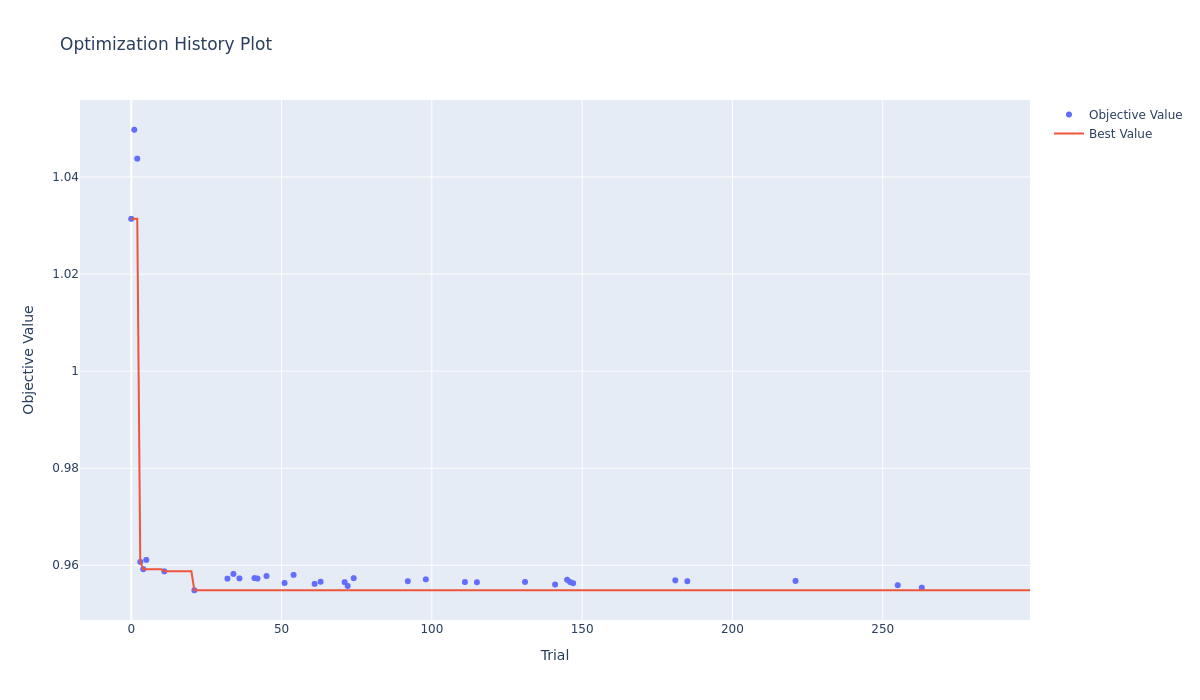

In [15]:
from optuna.visualization import plot_optimization_history
from src.visualization.plots import save_plotly_figure

fig = plot_optimization_history(study)
save_plotly_figure(fig, plots_dir / "optimization_history.png")

### Parameter Importances

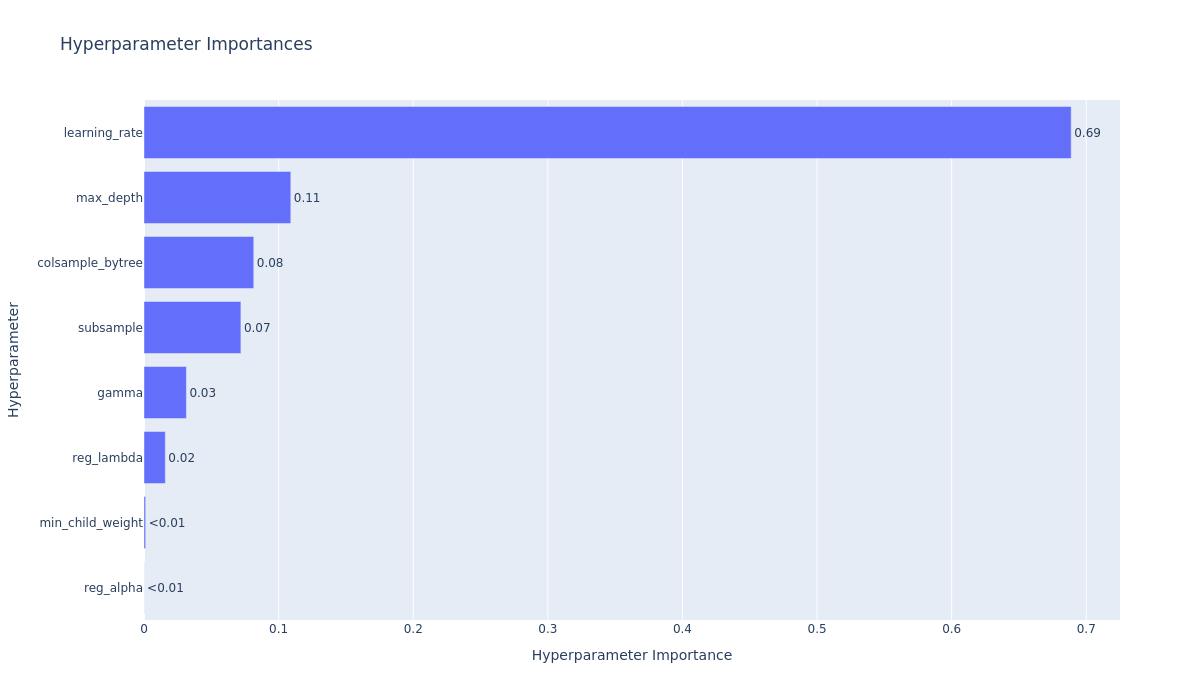

In [16]:
from optuna.visualization import plot_param_importances

if n_completed >= 2:
    fig = plot_param_importances(study)
    save_plotly_figure(fig, plots_dir / "param_importances.png")
else:
    print("Need at least 2 completed trials for parameter importance analysis")

### Contour Plot

Visualising pairwise interactions between hyperparameters. Darker regions indicate lower objective values.

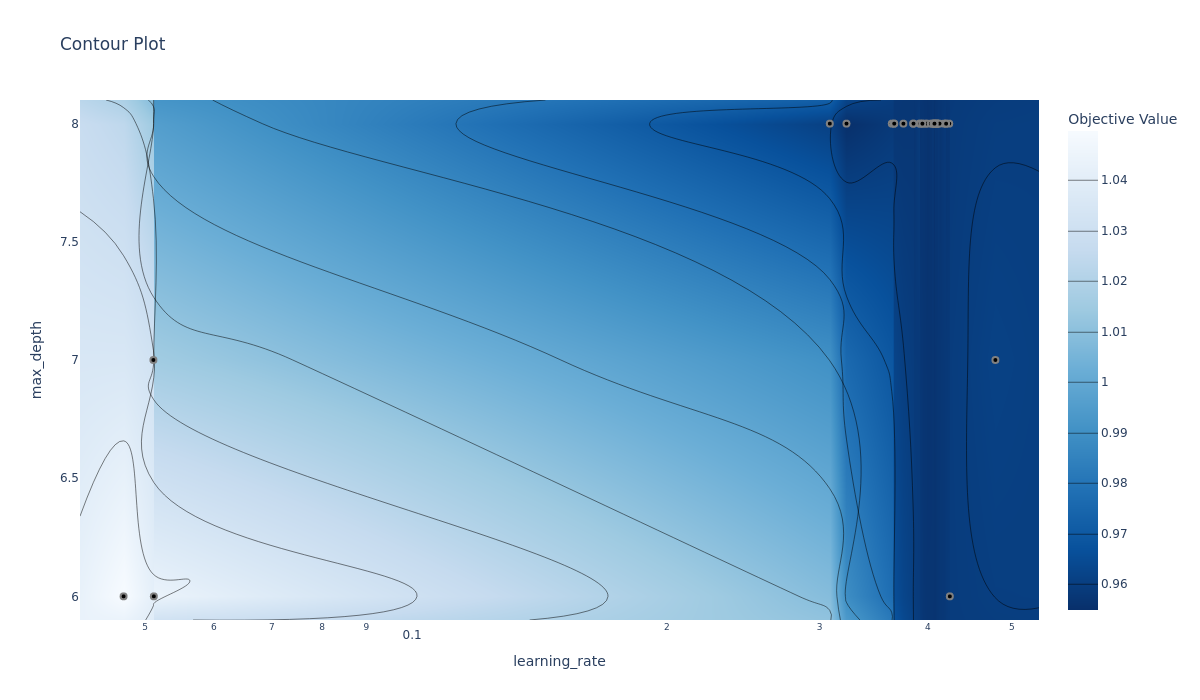

In [17]:
from optuna.visualization import plot_contour

if n_completed >= 2:
    fig = plot_contour(study, params=["learning_rate", "max_depth"])
    save_plotly_figure(fig, plots_dir / "contour.png")
else:
    print("Need at least 2 completed trials for contour plot")

### Parallel Coordinate Plot

Each line represents a trial. The colour encodes the objective value, revealing which parameter combinations yield the best results.

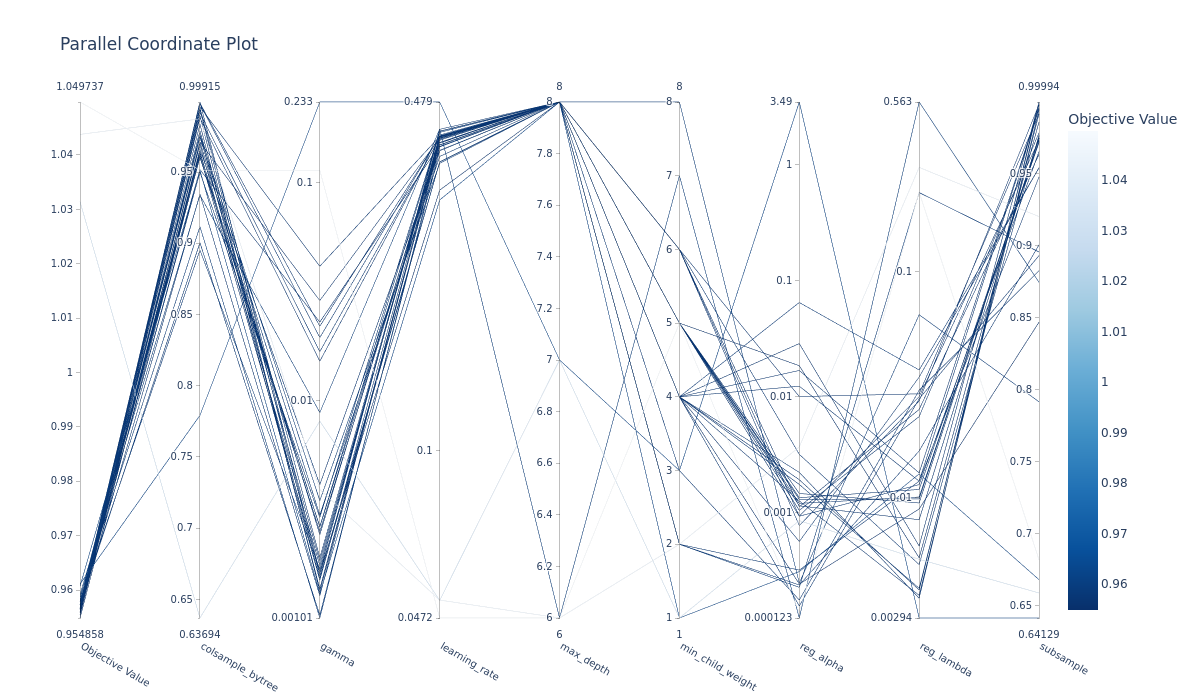

In [18]:
from optuna.visualization import plot_parallel_coordinate

if n_completed >= 2:
    fig = plot_parallel_coordinate(study)
    save_plotly_figure(fig, plots_dir / "parallel_coordinate.png")
else:
    print("Need at least 2 completed trials for parallel coordinate plot")

### Slice Plot

Marginal effect of each hyperparameter on the objective value.

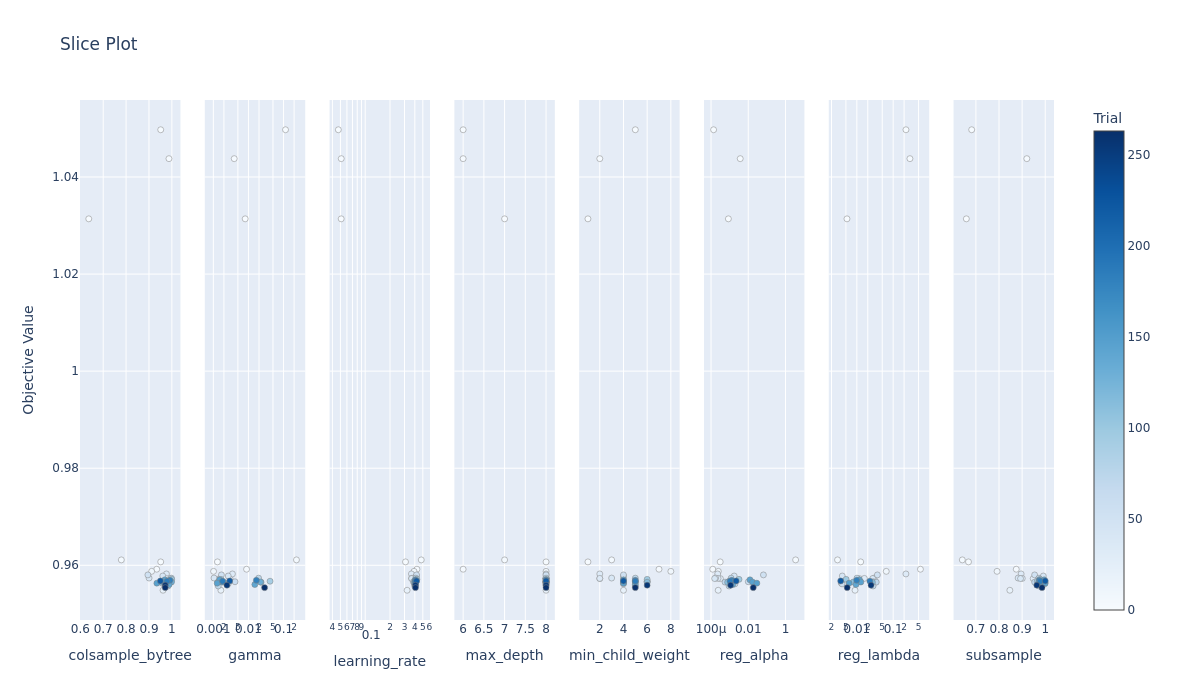

In [19]:
from optuna.visualization import plot_slice

if n_completed >= 2:
    fig = plot_slice(study)
    save_plotly_figure(fig, plots_dir / "slice.png")
else:
    print("Need at least 2 completed trials for slice plot")

## Export Best Parameters

Exporting the best trial's parameters as a Hydra-compatible YAML model config. This file can be copied to `configs/model/` and used for training:

```bash
cp <output_path> configs/model/xgboost_tuned.yaml
python run.py stage=train model=xgboost_tuned
```

In [20]:
from src.models.tuning import export_best_params

if n_completed > 0:
    suffix = "xgboost" if cfg.model.name == "xgboost" else "dnn"
    params_path = models_dir / f"{suffix}_best_params.yaml"
    export_best_params(study, cfg.model.name, cfg.model, params_path)
else:
    print("No completed trials — nothing to export")